<a href="https://colab.research.google.com/github/slouridorodriguez/candidates/blob/main/02_kpis_visualizaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop 1 - KPIs y visualizaciones

Todas las queries de acá abajo van contra la base de datos candidates_dw.sqlite que ya cargamos en el notebook 01_etl_pipeline.


In [1]:
# Importar librerías necesarias
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Conectar a la misma base de datos que ya armamos en el pipeline
ruta_base = "/content/drive/My Drive/Colab Notebooks/Curso ETL/datasets/"
ruta_dw = ruta_base + "candidates_dw.sqlite"

conn = sqlite3.connect(ruta_dw)


## KPI 1: hires por tecnología (pie chart)

In [4]:
query_tecnologia = """
SELECT t.Tecnologia, COUNT(*) AS contratados
FROM fact_postulaciones f
JOIN dim_tecnologia t ON f.tecnologia_id = t.tecnologia_id
WHERE f.is_hired = 1
GROUP BY t.Tecnologia
ORDER BY contratados DESC
"""

df_tecnologia = pd.read_sql(query_tecnologia, conn)
df_tecnologia


,Tecnologia,contratados
0,Development - CMS Backend,578
1,Sales,573
2,React Frontend,572
3,Client Success,558
4,Python Developer,551
5,DevOps,551
6,Adobe Experience Manager,549
7,Social Media Community Management,548
8,QA Manual,541
9,Java Backend,531


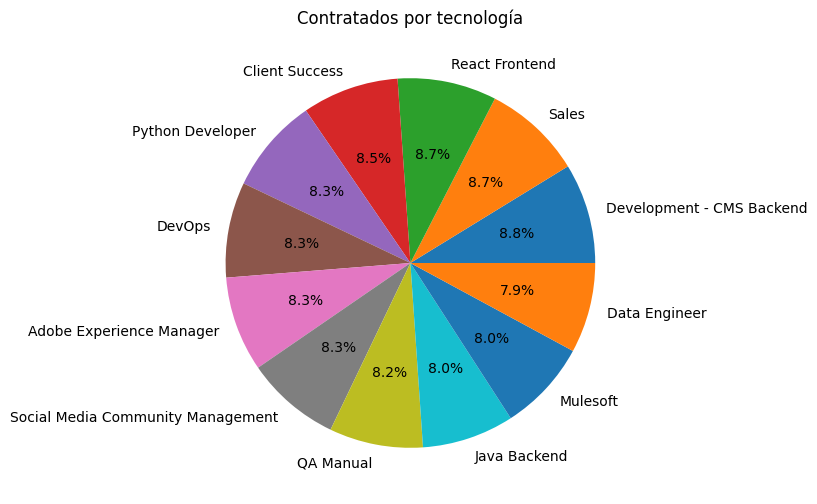

In [18]:
plt.figure(figsize=(6, 6))
plt.pie(df_tecnologia['contratados'], labels=df_tecnologia['Tecnologia'], autopct='%1.1f%%')
plt.title('Contratados por tecnología')
plt.show()


## KPI 2: hires por año (bar horizontal)

In [10]:
query_ano = """
SELECT d.Ano, COUNT(*) AS contratados
FROM fact_postulaciones f
JOIN dim_fecha d ON f.fecha_id = d.fecha_id
WHERE f.is_hired = 1
GROUP BY d.Ano
ORDER BY d.Ano
"""

df_ano = pd.read_sql(query_ano, conn)
df_ano


,Ano,contratados
0,2021,1094
1,2022,1351
2,2023,1336
3,2024,1295
4,2025,1336
5,2026,187


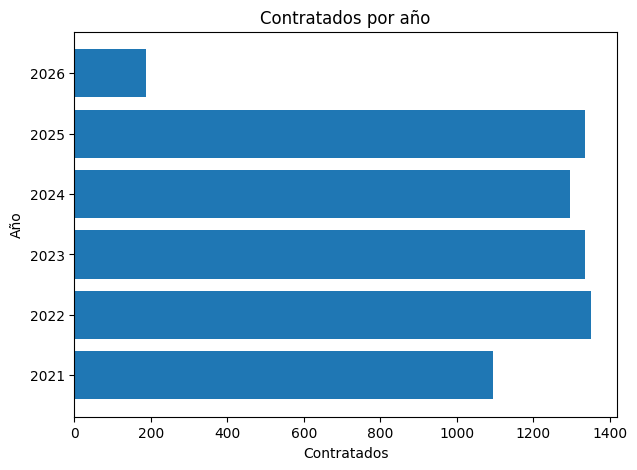

In [17]:
plt.figure(figsize=(7, 5))
plt.barh(df_ano['Ano'].astype(str), df_ano['contratados'])
plt.xlabel('Contratados')
plt.ylabel('Año')
plt.title('Contratados por año')
plt.show()


## KPI 3: hires por seniority (bar chart)

In [15]:
query_seniority = """
SELECT s.Seniority, COUNT(*) AS contratados
FROM fact_postulaciones f
JOIN dim_seniority s ON f.seniority_id = s.seniority_id
WHERE f.is_hired = 1
GROUP BY s.Seniority
ORDER BY contratados DESC
"""

df_seniority = pd.read_sql(query_seniority, conn)
df_seniority


,Seniority,contratados
0,Senior,927
1,Intern,921
2,Mid-Level,919
3,Manager,897
4,Lead,884
5,Junior,881
6,Trainee,846
7,Unknown,324


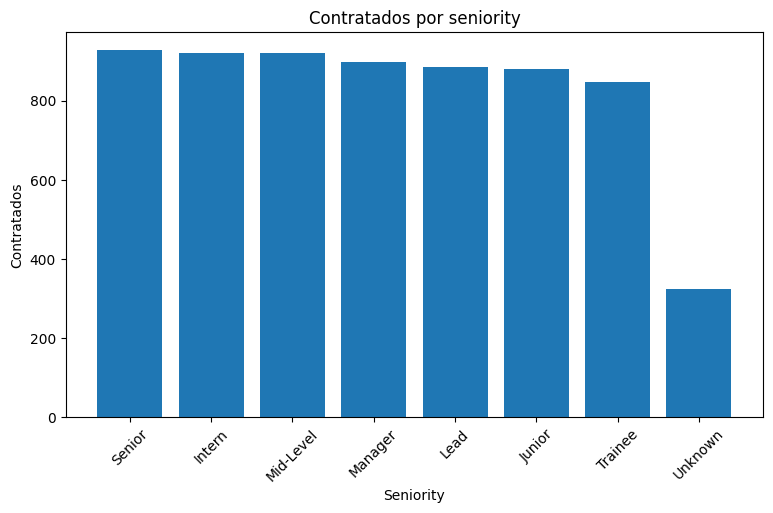

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(df_seniority['Seniority'], df_seniority['contratados'])
plt.xlabel('Seniority')
plt.ylabel('Contratados')
plt.title('Contratados por seniority')
plt.xticks(rotation=45)
plt.show()


## KPI 4: hires por país a lo largo de los años (multilínea, USA/Brasil/Colombia/Ecuador)

In [22]:
query_pais_ano = """
SELECT c.Pais, d.Ano, COUNT(*) AS contratados
FROM fact_postulaciones f
JOIN dim_candidatos c ON f.candidato_id = c.candidato_id
JOIN dim_fecha d ON f.fecha_id = d.fecha_id
WHERE f.is_hired = 1 AND c.Pais IN ('USA', 'Brazil', 'Colombia', 'Ecuador')
GROUP BY c.Pais, d.Ano
ORDER BY c.Pais, d.Ano
"""

df_pais_ano = pd.read_sql(query_pais_ano, conn)
df_pais_ano


,Pais,Ano,contratados
0,Brazil,2021,93
1,Brazil,2022,96
2,Brazil,2023,105
3,Brazil,2024,95
4,Brazil,2025,107
5,Brazil,2026,14
6,Colombia,2021,81
7,Colombia,2022,101
8,Colombia,2023,108
9,Colombia,2024,102


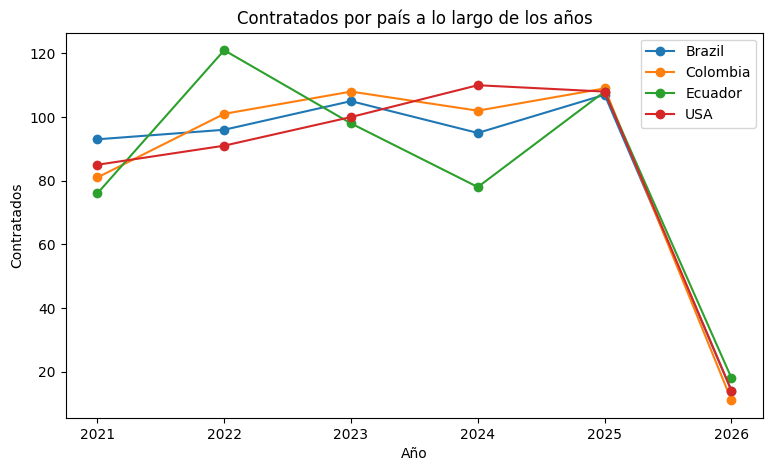

In [24]:
plt.figure(figsize=(9, 5))
for pais in df_pais_ano['Pais'].unique():
    datos_pais = df_pais_ano[df_pais_ano['Pais'] == pais]
    plt.plot(datos_pais['Ano'], datos_pais['contratados'], marker='o', label=pais)

plt.xlabel('Año')
plt.ylabel('Contratados')
plt.title('Contratados por país a lo largo de los años')
plt.legend()
plt.show()


In [25]:
conn.close()
